# 09 — E-Perf-1: Throughput Comparison (WAFER vs Native vs eKuiper)

> **SHAKEDOWN-MACOS — INFORMATIONAL ONLY.** Numbers below are from macOS
> Apple Silicon shakedown runs. They are NOT thesis-grade canonical results.

Pipeline A at 1000 msg/s steady. 30 runs per system.
Compares sustainable throughput across three systems on macOS shakedown.

Produces **Table 1** (throughput comparison) and **Figure 12** (throughput box plot).

In [1]:
import json, sys, os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wafer_analysis.paths import find_latest_shakedown

RESULT_DIR = find_latest_shakedown('e-perf-1')
print(f'Using: {RESULT_DIR}')

Using: <repo>/eval/results/e-perf-1/shakedown-macos-2026-08-01T19-50-15Z


In [2]:
# T9: apply thesis-grade matplotlib styling (font.family=serif, pdf.fonttype=42, mathtext=cm).
from wafer_analysis.plots import setup_thesis_style, save_figure
setup_thesis_style()


In [3]:
def load_system_data(system):
    """Load subscriber-metadata.json from all runs for a system."""
    runs = sorted(glob.glob(f'{RESULT_DIR}/{system}/run-*'))
    records = []
    for run_dir in runs:
        meta_path = os.path.join(run_dir, 'subscriber-metadata.json')
        if not os.path.exists(meta_path):
            continue
        with open(meta_path) as f:
            d = json.load(f)
        thr_path = os.path.join(run_dir, 'throughput.csv')
        thr = 0
        if os.path.exists(thr_path):
            df = pd.read_csv(thr_path)
            if 'throughput_msg_s' in df.columns and len(df) > 0:
                thr = df['throughput_msg_s'].iloc[0]
        records.append({
            'system': system,
            'total_recorded': d.get('total_recorded', 0),
            'p50_ns': d.get('latency_p50_ns', 0),
            'p95_ns': d.get('latency_p95_ns', 0),
            'p99_ns': d.get('latency_p99_ns', 0),
            'throughput_msg_s': thr,
            'parse_errors': d.get('parse_errors', 0),
            'gaps': d.get('sequence', {}).get('total_gaps', 0),
        })
    return pd.DataFrame(records)

wafer_df = load_system_data('wafer')
native_df = load_system_data('native')
ekuiper_df = load_system_data('ekuiper')
all_df = pd.concat([wafer_df, native_df, ekuiper_df], ignore_index=True)
print(f'Loaded: wafer={len(wafer_df)}, native={len(native_df)}, ekuiper={len(ekuiper_df)} runs')

Loaded: wafer=30, native=30, ekuiper=30 runs


In [4]:
# Summary statistics per system
summary = all_df.groupby('system').agg({
    'throughput_msg_s': ['median', 'mean', 'std'],
    'p50_ns': ['median'],
    'p99_ns': ['median'],
    'total_recorded': ['mean'],
    'gaps': ['sum'],
}).round(1)
print('\n=== Throughput Summary (msg/s) ===')
print(summary)

# Compute ratios
wafer_thr = wafer_df['throughput_msg_s'].median()
native_thr = native_df['throughput_msg_s'].median()
ekuiper_thr = ekuiper_df['throughput_msg_s'].median()
print(f'\n=== Throughput Ratios ===')
print(f'WAFER/native: {wafer_thr/native_thr:.3f}')
print(f'WAFER/eKuiper: {wafer_thr/ekuiper_thr:.3f}')


=== Throughput Summary (msg/s) ===
        throughput_msg_s                 p50_ns     p99_ns total_recorded gaps
                  median   mean  std     median     median           mean  sum
system                                                                        
ekuiper            893.6  893.4  1.8  1074175.0  1982463.0         9000.0    0
native             811.8  812.0  0.8  1272831.0  2052095.0         9000.0    0
wafer              811.2  810.9  1.7  1289727.0  2163711.0         9000.0    0

=== Throughput Ratios ===
WAFER/native: 0.999
WAFER/eKuiper: 0.908


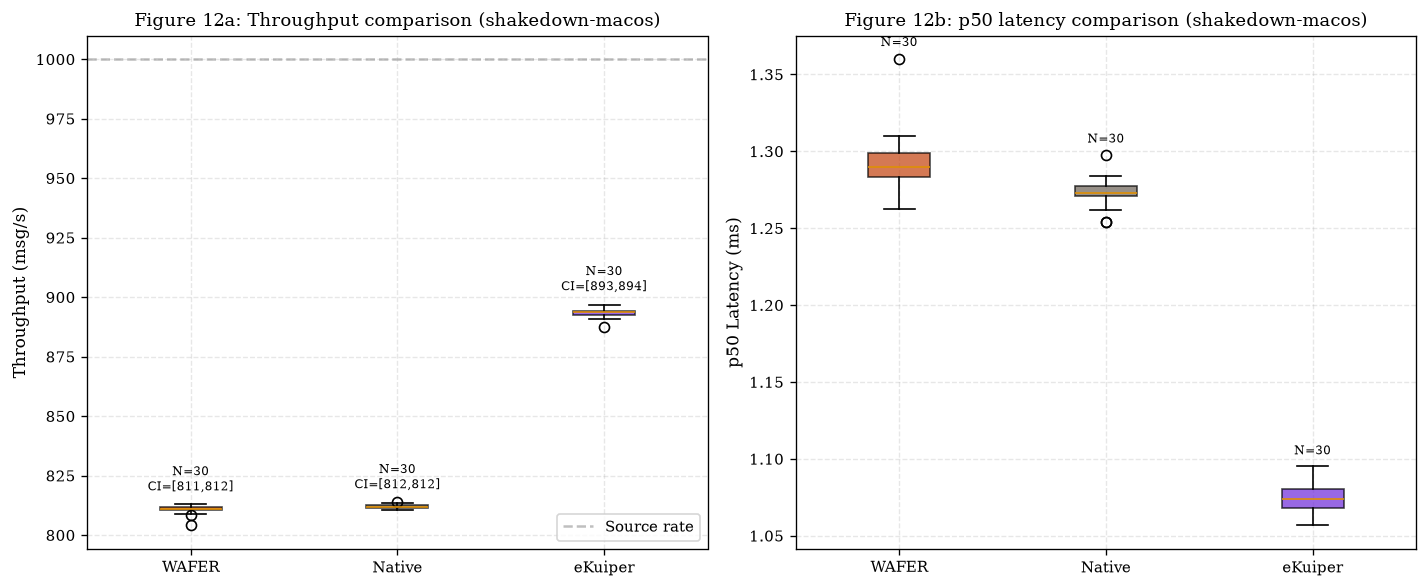

saved thesis figure to ../figures/e-perf-1/throughput.pdf


In [5]:
# Box plot of throughput per system
from wafer_analysis.plots import SYSTEM_COLORS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

systems       = ['wafer', 'native', 'ekuiper']
display_names = ['WAFER', 'Native', 'eKuiper']
colors = [SYSTEM_COLORS['WAFER'], SYSTEM_COLORS['Native'], SYSTEM_COLORS['eKuiper']]

data_thr = [all_df[all_df.system == s]['throughput_msg_s'].values for s in systems]

# Bootstrap 95% CI on median
rng = np.random.default_rng(42)
def _boot_ci_median(arr, n_boot=2000):
    if len(arr) == 0:
        return (0.0, 0.0)
    samples = rng.choice(arr, size=(n_boot, len(arr)), replace=True)
    meds = np.median(samples, axis=1)
    return (np.percentile(meds, 2.5), np.percentile(meds, 97.5))

bp1 = ax1.boxplot(data_thr, tick_labels=display_names, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('Throughput (msg/s)')
ax1.set_title('Figure 12a: Throughput comparison (shakedown-macos)')
ax1.axhline(y=1000, color='gray', linestyle='--', alpha=0.5, label='Source rate')
ax1.legend(loc='lower right')

# Annotate N + bootstrap CI-95 above each box
for i, (d, name) in enumerate(zip(data_thr, display_names)):
    n = len(d)
    lo, hi = _boot_ci_median(d)
    y_top = np.max(d) if n > 0 else 1000
    ax1.text(i + 1, y_top * 1.005,
             f'N={n}\nCI=[{lo:.0f},{hi:.0f}]',
             ha='center', va='bottom', fontsize=7)

# Box plot of p50 latency
data_lat = [all_df[all_df.system == s]['p50_ns'].values / 1e6 for s in systems]
bp2 = ax2.boxplot(data_lat, tick_labels=display_names, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('p50 Latency (ms)')
ax2.set_title('Figure 12b: p50 latency comparison (shakedown-macos)')

for i, d in enumerate(data_lat):
    n = len(d)
    y_top = np.max(d) if n > 0 else 1.0
    ax2.text(i + 1, y_top * 1.005, f'N={n}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('../../results/e-perf-1/throughput-comparison.png', dpi=150, bbox_inches='tight')
plt.show()
# T9: persist thesis figure to ../figures/e-perf-1/throughput.{pdf,png}
_saved = save_figure(fig, 'e-perf-1/throughput')
print(f'saved thesis figure to {_saved}')